# Consultas Operacionais no DuckDB e Consumo da API

Este notebook foi criado para enriquecer a camada operacional do projeto. O foco aqui nao e treinar modelos, e sim mostrar como consultar o banco local de MLOps, inspecionar logs de previsao, acompanhar alertas de drift e consumir a API de inferencia de forma reproduzivel.

De forma pratica, o notebook cobre duas frentes:

1. consulta analitica ao banco `artifacts/database/ml_ops.duckdb`;
2. chamadas HTTP para a API de churn, incluindo `health`, `ready`, metadata do modelo e predicao.

## Plano de exploracao

- conectar ao banco DuckDB e listar as tabelas operacionais;
- consultar o registro de modelos, logs de previsao e alertas de drift;
- criar visualizacoes simples para tornar a camada operacional mais tangivel;
- preparar payloads de exemplo e consumir a API;
- registrar boas praticas de uso para demonstracao em portfolio.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import duckdb
import httpx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", palette="crest")

In [2]:
try:
    base_dir = Path(__file__).resolve().parent
except NameError:
    base_dir = Path.cwd()

ROOT_DIR = base_dir.parent
DB_PATH = ROOT_DIR / "artifacts" / "database" / "ml_ops.duckdb"
API_BASE_URL = "http://127.0.0.1:8000"

assert DB_PATH.exists(), f"Banco nao encontrado em: {DB_PATH}"
DB_PATH

WindowsPath('c:/Users/Guilherme Cavalheri/Desktop/github/telecom-churn-prediction/artifacts/database/ml_ops.duckdb')

## Contexto operacional

O banco DuckDB funciona como uma camada leve de persistencia operacional. Ele nao substitui uma infraestrutura de producao, mas serve muito bem para portfolio porque concentra historico de modelos, previsoes e monitoramento em um unico artefato consultavel.

Neste projeto, o banco e usado para registrar:

- versoes de modelo;
- logs de previsao;
- amostras de payload;
- snapshots de monitoramento;
- alertas de drift.

In [3]:
connection = duckdb.connect(str(DB_PATH))

tables_df = connection.execute("SHOW TABLES").fetchdf()
tables_df

,name
0,drift_alerts
1,model_registry
2,monitoring_snapshots
3,prediction_inputs_sample
4,prediction_logs


## Registro de modelos

A tabela `model_registry` permite responder rapidamente qual versao do modelo esta em uso, qual threshold foi adotado e quais metricas foram registradas no momento da persistencia. Essa camada e importante para rastreabilidade e governanca minima do ciclo de vida do modelo.

In [4]:
model_registry_df = connection.execute("SELECT * FROM model_registry ORDER BY created_at_utc DESC").fetchdf()
model_registry_df

,model_version,model_name,created_at_utc,threshold,bundle_path,metadata_path,metrics_json
0,xgboost_2026-03-13T20:47:36+00:00,XGBoost,2026-03-13 20:47:36,0.5,C:\Users\Guilherme Cavalheri\Desktop\github\te...,C:\Users\Guilherme Cavalheri\Desktop\github\te...,"{""model"": ""XGBoost"", ""test_accuracy"": 0.9596, ..."


## Logs de previsao

A tabela `prediction_logs` mostra o historico de inferencia. Em um cenario real, ela ajudaria a responder perguntas como:

- qual modelo gerou determinada previsao;
- qual foi o score retornado;
- qual a origem do lote ou request;
- como a distribuicao dos scores mudou ao longo do tempo.

In [5]:
prediction_logs_df = connection.execute("SELECT * FROM prediction_logs ORDER BY prediction_timestamp_utc DESC LIMIT 500").fetchdf()
prediction_logs_df.head()

,prediction_timestamp_utc,request_id,source,model_name,model_version,score,predicted_label,threshold
0,2026-03-13 22:42:35,1e12eb6d-2980-4d09-92ec-c4d3d6aed849,notebook_batch_demo,XGBoost,xgboost_2026-03-13T20:47:36+00:00,0.997808,1,0.5
1,2026-03-13 22:42:35,b85c3afc-be8c-4ae0-9d70-ab13a3b3d126,notebook_batch_demo,XGBoost,xgboost_2026-03-13T20:47:36+00:00,0.950390,1,0.5
2,2026-03-13 22:42:34,d17422bc-2f13-4ba7-9502-af8dd1f9aa71,api_single,XGBoost,xgboost_2026-03-13T20:47:36+00:00,0.950390,1,0.5
3,2026-03-13 21:05:17,66849b80-8839-4627-a76f-32c5726cf829,synthetic_baseline,XGBoost,xgboost_2026-03-13T20:47:36+00:00,0.000264,0,0.5
4,2026-03-13 21:05:17,6bb65b10-7220-46f2-bf96-4198b0921d04,synthetic_baseline,XGBoost,xgboost_2026-03-13T20:47:36+00:00,0.003838,0,0.5


## Visual 1: distribuicao dos scores previstos

**O que o grafico mostra:** a distribuicao dos scores de churn gravados no log operacional.

**Por que ele e importante:** esse grafico ajuda a entender o comportamento geral do modelo em producao ou em ambiente de simulacao. Ele mostra se os scores estao concentrados em baixo risco, alto risco ou em uma regiao intermediaria.

**Insight esperado:** em cenarios com drift, e comum observar deslocamento dessa distribuicao, especialmente quando o risco previsto aumenta de forma agregada.

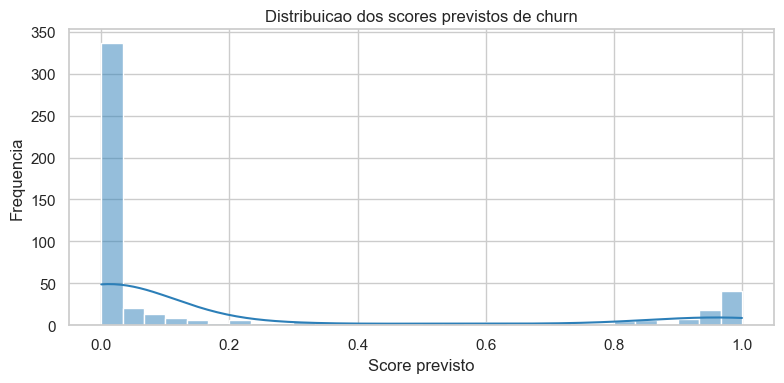

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(prediction_logs_df["score"], bins=30, kde=True, color="#2c7fb8")
plt.title("Distribuicao dos scores previstos de churn")
plt.xlabel("Score previsto")
plt.ylabel("Frequencia")
plt.tight_layout()
plt.show()

## Visual 2: volume de previsoes por origem

**O que o grafico mostra:** quantas previsoes foram registradas por origem (`source`).

**Por que ele e importante:** essa leitura ajuda a separar trafego vindo de simulacoes, lotes de monitoramento e chamadas de API. Em um sistema real, esse tipo de agregacao permite identificar crescimento de uso, mudancas no perfil de consumo e anomalias de operacao.

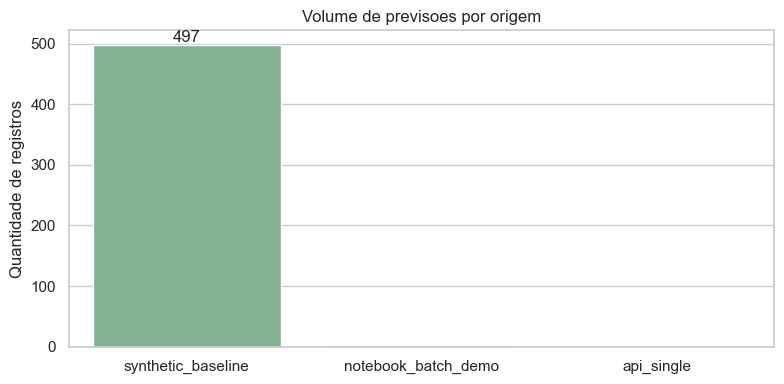

,source,count
0,synthetic_baseline,497
1,notebook_batch_demo,2
2,api_single,1


In [7]:
source_volume_df = prediction_logs_df["source"].value_counts().rename_axis("source").reset_index(name="count")

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=source_volume_df, x="source", y="count", hue="source", dodge=False, legend=False)
ax.bar_label(ax.containers[0])
plt.title("Volume de previsoes por origem")
plt.xlabel("")
plt.ylabel("Quantidade de registros")
plt.tight_layout()
plt.show()

source_volume_df

## Alertas e monitoramento

As tabelas `monitoring_snapshots` e `drift_alerts` aproximam o projeto de uma disciplina de MLOps. Elas permitem recuperar quais features apresentaram deslocamento estatistico e quais sinais justificaram um alerta de investigacao.

In [8]:
monitoring_snapshot_df = connection.execute("SELECT * FROM monitoring_snapshots ORDER BY observed_at_utc DESC LIMIT 200").fetchdf()
drift_alerts_df = connection.execute("SELECT * FROM drift_alerts ORDER BY alert_timestamp_utc DESC LIMIT 50").fetchdf()

display(Markdown("### Snapshot de monitoramento"))
display(monitoring_snapshot_df.head())
display(Markdown("### Alertas de drift"))
display(drift_alerts_df)

### Snapshot de monitoramento

,run_id,observed_at_utc,dataset_label,feature_name,reference_mean,current_mean,reference_std,current_std,reference_missing_rate,current_missing_rate,psi,drift_severity
0,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,status,1.226000,1.226000,0.418658,0.418658,0.0,0.0,0.000000,low
1,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,seconds_of_use,4458.876000,3483.318000,4090.017796,3226.158873,0.0,0.0,0.099250,low
2,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,customer_value,515.985528,438.993314,574.684915,492.131634,0.0,0.0,0.042106,low
3,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,call_failure,7.540000,15.490000,6.995876,12.738227,0.0,0.0,0.670330,high
4,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,tariff_plan,1.084000,1.084000,0.277666,0.277666,0.0,0.0,0.000000,low


### Alertas de drift

,run_id,alert_timestamp_utc,feature_name,psi,severity,message,recommended_action
0,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,call_failure,0.670330,high,Feature 'call_failure' shows high drift with P...,Review recent scoring batches and assess wheth...
1,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,subscription_length,0.614612,high,Feature 'subscription_length' shows high drift...,Review recent scoring batches and assess wheth...
2,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,frequency_of_use,0.191292,moderate,Feature 'frequency_of_use' shows moderate drif...,Review recent scoring batches and assess wheth...
3,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,predicted_churn_rate,NaN,high,Predicted churn rate changed materially betwee...,"Investigate operational changes, validate drif..."
4,b4df4539-8cb0-4d72-ab58-b06c4f6422ed,2026-03-13 21:04:42,call_failure,0.670330,high,Feature 'call_failure' shows high drift with P...,Review recent scoring batches and assess wheth...
5,b4df4539-8cb0-4d72-ab58-b06c4f6422ed,2026-03-13 21:04:42,subscription_length,0.614612,high,Feature 'subscription_length' shows high drift...,Review recent scoring batches and assess wheth...
6,b4df4539-8cb0-4d72-ab58-b06c4f6422ed,2026-03-13 21:04:42,frequency_of_use,0.191292,moderate,Feature 'frequency_of_use' shows moderate drif...,Review recent scoring batches and assess wheth...
7,b4df4539-8cb0-4d72-ab58-b06c4f6422ed,2026-03-13 21:04:42,predicted_churn_rate,NaN,high,Predicted churn rate changed materially betwee...,"Investigate operational changes, validate drif..."
8,6c26527a-0266-409d-9c5a-c3111524b3bc,2026-03-13 21:01:07,call_failure,0.670330,high,Feature 'call_failure' shows high drift with P...,Review recent scoring batches and assess wheth...
9,6c26527a-0266-409d-9c5a-c3111524b3bc,2026-03-13 21:01:07,subscription_length,0.614612,high,Feature 'subscription_length' shows high drift...,Review recent scoring batches and assess wheth...


## Visual 3: PSI por feature monitorada

**O que o grafico mostra:** o PSI mais recente por feature monitorada.

**Por que ele e importante:** ele transforma o monitoramento em algo rapidamente auditavel, destacando quais variaveis estao mais distantes da referencia historica.

**Insight esperado:** features com PSI maior tendem a ser candidatas prioritarias para investigacao de drift e possivel preparacao de retreinamento.

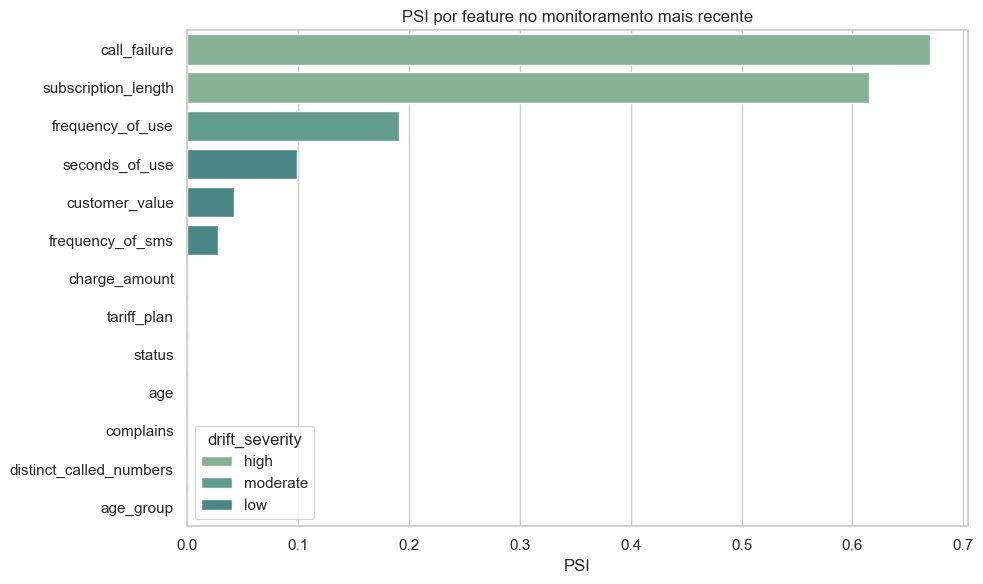

C:\Users\Guilherme Cavalheri\AppData\Local\Temp\ipykernel_10400\3141600588.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_snapshot_df.sort_values("psi", ascending=False).round(4)


,run_id,observed_at_utc,dataset_label,feature_name,reference_mean,current_mean,reference_std,current_std,reference_missing_rate,current_missing_rate,psi,drift_severity
3,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,call_failure,7.5400,15.4900,6.9959,12.7382,0.0,0.0,0.6703,high
10,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,subscription_length,32.3800,28.4360,8.7208,8.0196,0.0,0.0,0.6146,high
5,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,frequency_of_use,71.0220,50.9260,56.7472,41.4528,0.0,0.0,0.1913,moderate
1,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,seconds_of_use,4458.8760,3483.3180,4090.0178,3226.1589,0.0,0.0,0.0993,low
2,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,customer_value,515.9855,438.9933,574.6849,492.1316,0.0,0.0,0.0421,low
7,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,frequency_of_sms,84.6680,71.3440,132.2798,112.5255,0.0,0.0,0.0282,low
11,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,charge_amount,0.8900,0.9220,1.3437,1.4752,0.0,0.0,0.0000,low
4,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,tariff_plan,1.0840,1.0840,0.2777,0.2777,0.0,0.0,0.0000,low
0,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,status,1.2260,1.2260,0.4187,0.4187,0.0,0.0,0.0000,low
8,a1fc6e31-c441-454d-bf8b-b67a602e8330,2026-03-13 21:05:18,synthetic_api_drift_demo,age,30.7600,30.7600,8.6933,8.6933,0.0,0.0,0.0000,low


In [9]:
latest_run_id = monitoring_snapshot_df["run_id"].iloc[0] if not monitoring_snapshot_df.empty else None
latest_snapshot_df = monitoring_snapshot_df.loc[monitoring_snapshot_df["run_id"] == latest_run_id].copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=latest_snapshot_df.sort_values("psi", ascending=False), x="psi", y="feature_name", hue="drift_severity", dodge=False)
plt.title("PSI por feature no monitoramento mais recente")
plt.xlabel("PSI")
plt.ylabel("")
plt.tight_layout()
plt.show()

latest_snapshot_df.sort_values("psi", ascending=False).round(4)

## Consumo da API

A partir daqui, o notebook passa a usar a API de inferencia. Para que as celulas abaixo funcionem, o servidor precisa estar em execucao.

Comando sugerido:

```bash
uvicorn api.app:app --reload
```

A API agora diferencia dois tipos de checagem operacional:

- `GET /health`: confirma apenas que o servico esta vivo;
- `GET /ready`: confirma que o servico esta pronto para operar, incluindo modelo, metadata e acesso ao banco local.

Se a API nao estiver no ar, as chamadas HTTP vao falhar, o que e esperado.

In [10]:
health_response = httpx.get(f"{API_BASE_URL}/health", timeout=30.0)
health_response.raise_for_status()
health_response.json()

{'status': 'ok', 'service': 'alive'}

## Endpoint de readiness

O endpoint `GET /ready` vai alem do liveness simples. Ele verifica se a API esta realmente pronta para operar, incluindo bundle do modelo carregado, metadata ativa e acesso ao banco com as tabelas operacionais esperadas.

Esse tipo de endpoint fortalece a demonstracao de MLOps porque mostra a diferenca entre um servico apenas no ar e um servico realmente apto a receber trafego de previsao.

In [12]:
connection.close()

In [13]:
ready_response = httpx.get(f"{API_BASE_URL}/ready", timeout=30.0)
ready_response.raise_for_status()
ready_response.json()

{'status': 'ready',
 'checks': {'model_bundle_loaded': True,
  'model_metadata_loaded': True,
  'model_version': 'xgboost_2026-03-13T20:47:36+00:00',
  'threshold': 0.5,
  'expected_input_columns': ['call_failure',
   'complains',
   'subscription_length',
   'charge_amount',
   'seconds_of_use',
   'frequency_of_use',
   'frequency_of_sms',
   'distinct_called_numbers',
   'age_group',
   'tariff_plan',
   'status',
   'age',
   'customer_value'],
  'database_accessible': True,
  'database_path': 'C:\\Users\\Guilherme Cavalheri\\Desktop\\github\\telecom-churn-prediction\\artifacts\\database\\ml_ops.duckdb',
  'existing_tables': ['drift_alerts',
   'model_registry',
   'monitoring_snapshots',
   'prediction_inputs_sample',
   'prediction_logs'],
  'missing_tables': [],
  'required_tables_available': True}}

In [14]:
model_info_response = httpx.get(f"{API_BASE_URL}/model/info", timeout=30.0)
model_info_response.raise_for_status()
model_info_response.json()

{'model_name': 'XGBoost',
 'model_version': 'xgboost_2026-03-13T20:47:36+00:00',
 'threshold': 0.5,
 'feature_columns': ['call_failure',
  'complains',
  'subscription_length',
  'charge_amount',
  'seconds_of_use',
  'frequency_of_use',
  'frequency_of_sms',
  'distinct_called_numbers',
  'age_group',
  'tariff_plan',
  'status',
  'age',
  'customer_value',
  'avg_seconds_per_call',
  'sms_per_call',
  'calls_per_contact',
  'contact_diversity_ratio',
  'call_failure_rate',
  'usage_per_month',
  'calls_per_month',
  'sms_per_month',
  'value_per_month',
  'value_per_call',
  'complaint_status_interaction',
  'charge_value_gap',
  'tenure_age_ratio',
  'usage_value_efficiency'],
 'raw_input_columns': ['call_failure',
  'complains',
  'subscription_length',
  'charge_amount',
  'seconds_of_use',
  'frequency_of_use',
  'frequency_of_sms',
  'distinct_called_numbers',
  'age_group',
  'tariff_plan',
  'status',
  'age',
  'customer_value']}

## Chamada unitaria a API

A chamada unitaria e a forma mais simples de demonstrar a integracao entre camada de servico e pipeline salvo. Ela e util para mostrar o contrato da API e como o score pode ser consultado a partir de um payload bruto.

In [15]:
sample_payload = {
    "call_failure": 3,
    "complains": 1,
    "subscription_length": 14,
    "charge_amount": 2,
    "seconds_of_use": 980,
    "frequency_of_use": 21,
    "frequency_of_sms": 11,
    "distinct_called_numbers": 8,
    "age_group": 3,
    "tariff_plan": 1,
    "status": 2,
    "age": 31,
    "customer_value": 88.75,
}

predict_response = httpx.post(f"{API_BASE_URL}/predict", json=sample_payload, timeout=30.0)
predict_response.raise_for_status()
predict_response.json()

{'prediction': {'prediction_timestamp_utc': '2026-03-14T04:16:20+00:00',
  'request_id': '4d6e18d1-7bfc-41b7-8c5f-865e95819995',
  'source': 'api_single',
  'model_name': 'XGBoost',
  'model_version': 'xgboost_2026-03-13T20:47:36+00:00',
  'score': 0.9503904581069946,
  'predicted_label': 1,
  'threshold': 0.5},
 'warnings': []}

## Chamada em lote a API

A chamada batch e mais proxima de um cenario operacional, em que varios registros sao submetidos ao modelo de uma vez. Isso e especialmente util para scoring de campanhas, testes de monitoramento ou enriquecimento de bases.

In [16]:
batch_payload = {
    "source": "notebook_batch_demo",
    "records": [
        sample_payload,
        {
            "call_failure": 9,
            "complains": 1,
            "subscription_length": 9,
            "charge_amount": 4,
            "seconds_of_use": 520,
            "frequency_of_use": 10,
            "frequency_of_sms": 4,
            "distinct_called_numbers": 5,
            "age_group": 4,
            "tariff_plan": 2,
            "status": 1,
            "age": 44,
            "customer_value": 41.25,
        },
    ],
}

batch_response = httpx.post(f"{API_BASE_URL}/predict/batch", json=batch_payload, timeout=30.0)
batch_response.raise_for_status()
batch_body = batch_response.json()
pd.DataFrame(batch_body["predictions"]).round(4)

,prediction_timestamp_utc,request_id,source,model_name,model_version,score,predicted_label,threshold
0,2026-03-14T04:16:21+00:00,d1b619c4-347a-4ebf-8369-ef65c1d6198d,notebook_batch_demo,XGBoost,xgboost_2026-03-13T20:47:36+00:00,0.9504,1,0.5
1,2026-03-14T04:16:21+00:00,658b8039-3567-41d1-8263-07d3637dfdfd,notebook_batch_demo,XGBoost,xgboost_2026-03-13T20:47:36+00:00,0.9978,1,0.5


## Conclusao

Este notebook adiciona uma camada importante de portfolio ao projeto: ele mostra que o sistema nao termina no treino do modelo. A partir do banco operacional e da API, fica possivel demonstrar rastreabilidade, observabilidade, consumo do servico e leitura analitica de operacao em um mesmo fluxo.

Em outras palavras, o notebook ajuda a comunicar que o projeto nao e apenas um experimento de modelagem, mas uma base organizada para um caso de uso mais proximo de MLOps aplicado.